<a href="https://colab.research.google.com/github/Jahnavi-711/DL-Lab-Work/blob/main/DL_EXP_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)

In [2]:
(X_train, _), (X_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train = np.reshape(
    X_train,
    (len(X_train), 28, 28, 1)
)

X_test = np.reshape(
    X_test,
    (len(X_test), 28, 28, 1)
)

print("Training Shape:", X_train.shape)

Training Shape: (60000, 28, 28, 1)


In [4]:
# Encoder
input_img = Input(shape=(28,28,1))

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = Conv2D(
    16,
    (3,3),
    activation='relu',
    padding='same'
)(x)

encoded = MaxPooling2D(
    (2,2),
    padding='same'
)(x)


# Decoder
x = Conv2D(
    16,
    (3,3),
    activation='relu',
    padding='same'
)(encoded)

x = UpSampling2D((2,2))(x)

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = UpSampling2D((2,2))(x)

decoded = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

In [5]:
autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test, X_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 141ms/step - loss: 0.1319 - val_loss: 0.0806
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 131ms/step - loss: 0.0786 - val_loss: 0.0755
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 127ms/step - loss: 0.0751 - val_loss: 0.0736
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 129ms/step - loss: 0.0732 - val_loss: 0.0717
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - loss: 0.0719 - val_loss: 0.0707
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 128ms/step - loss: 0.0710 - val_loss: 0.0699
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 128ms/step - loss: 0.0703 - val_loss: 0.0694
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 131ms/step - loss: 0.0697 - val_loss: 0.0688
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 140ms/step - loss: 0.0692 - val_loss: 0.0685
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 133ms/step - loss: 0.0689 - val_loss: 0.0683


In [7]:
decoded_imgs = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


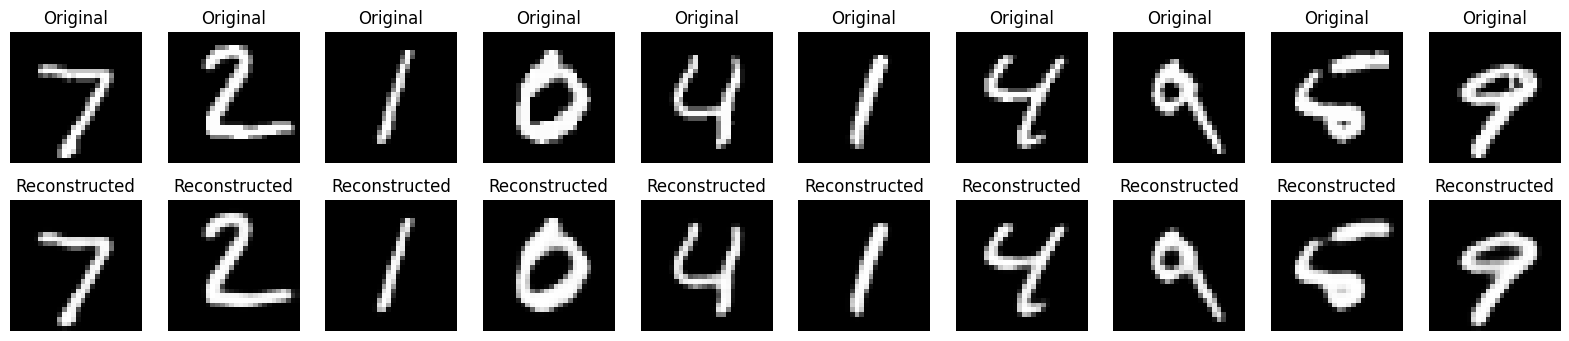

In [8]:
n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # Original Image
    ax = plt.subplot(2, n, i + 1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title("Original")

    plt.axis('off')

    # Reconstructed Image
    ax = plt.subplot(2, n, i + 1 + n)

    plt.imshow(
        decoded_imgs[i].reshape(28,28),
        cmap='gray'
    )
    plt.title("Reconstructed")

    plt.axis('off')

plt.show()

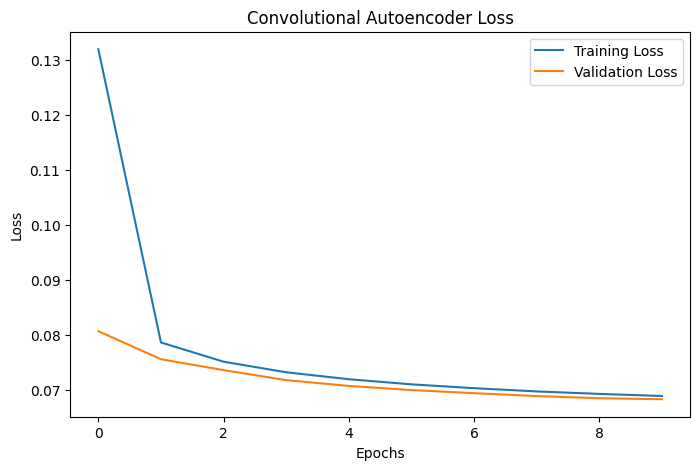

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Convolutional Autoencoder Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()